# Pipeline d'optimisation de portefeuille Markowitz

Ce notebook construit une pipeline simple d'allocation d'actifs à partir de prix historiques.
L'objectif est d'estimer les rendements et les risques, puis de comparer plusieurs portefeuilles optimisés.
La frontière efficiente simulée donne une lecture visuelle du compromis rendement-risque.
Les dernières sections ajoutent des mesures de risque, une simulation Monte Carlo, un backtest hors échantillon et un clustering de profils investisseurs.


## 1. Imports et configuration

Les paramètres principaux sont regroupés ici pour rendre les hypothèses faciles à modifier.
La seed est fixée pour reproduire les simulations aléatoires.
La fréquence annuelle retenue est de 252 jours de cotation.


In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.optimize import minimize

try:
    import yfinance as yf
    YFINANCE_AVAILABLE = True
except ImportError:
    yf = None
    YFINANCE_AVAILABLE = False

SEED = 42
RNG = np.random.default_rng(SEED)

TICKERS = ["AAPL", "MSFT", "JPM", "XOM", "KO", "AMZN", "PFE", "TSLA"]
START_DATE = "2020-01-01"
END_DATE = "2026-01-01"
TRADING_DAYS = 252
RISK_FREE_RATE = 0.02
N_SIMULATIONS = 10_000
MAX_WEIGHT = 0.40
MAX_SECTOR_WEIGHT = 0.55

SECTOR_MAP = {
    "AAPL": "Technology",
    "MSFT": "Technology",
    "AMZN": "Consumer",
    "TSLA": "Consumer",
    "JPM": "Financials",
    "XOM": "Energy",
    "KO": "Defensive",
    "PFE": "Healthcare",
}

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
warnings.filterwarnings("ignore", category=FutureWarning)

try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("default")


## 2. Théorie minimale

Pour un vecteur de poids $w$, un vecteur de rendements annualisés $\mu$ et une matrice de covariance $\Sigma$:

$$R_p = w^\top\mu$$
$$\sigma_p^2 = w^\top\Sigma w$$
$$SR = \frac{R_p - r_f}{\sigma_p}$$

Les optimisations imposent en général $\sum_i w_i = 1$ et des poids bornés.


## 3. Chargement ou génération des données

Le notebook essaie de télécharger des prix ajustés avec `yfinance`.
Si les données ne sont pas accessibles, une série synthétique corrélée est générée.
Le fallback permet de conserver une pipeline exécutable hors ligne.


In [2]:
def generate_synthetic_prices(tickers, start, end, seed=SEED, initial_price=100):
    """Generate correlated synthetic prices for offline execution."""
    rng = np.random.default_rng(seed)
    dates = pd.bdate_range(start=start, end=end)
    n_assets = len(tickers)

    annual_returns = np.linspace(0.04, 0.12, n_assets)
    annual_vols = np.linspace(0.14, 0.32, n_assets)
    corr = np.full((n_assets, n_assets), 0.30)
    np.fill_diagonal(corr, 1.0)

    annual_cov = np.outer(annual_vols, annual_vols) * corr
    daily_mean = (annual_returns - 0.5 * annual_vols**2) / TRADING_DAYS
    daily_cov = annual_cov / TRADING_DAYS

    log_returns = rng.multivariate_normal(daily_mean, daily_cov, size=len(dates))
    prices = initial_price * np.exp(np.cumsum(log_returns, axis=0))
    return pd.DataFrame(prices, index=dates, columns=tickers)


def download_prices(tickers, start, end):
    """Download adjusted close prices with yfinance."""
    if not YFINANCE_AVAILABLE:
        raise ImportError("yfinance is not installed")

    data = yf.download(
        tickers=tickers,
        start=start,
        end=end,
        auto_adjust=True,
        progress=False,
        group_by="column",
    )
    if data.empty:
        raise ValueError("empty data returned by yfinance")

    prices = data["Close"] if isinstance(data.columns, pd.MultiIndex) else data[["Close"]]
    if not isinstance(prices, pd.DataFrame):
        prices = prices.to_frame()
    if prices.shape[1] == 1:
        prices.columns = tickers[:1]

    prices = prices.sort_index().ffill().dropna(axis=1, how="all").dropna()
    if prices.shape[0] < 100 or prices.shape[1] < 3:
        raise ValueError("not enough usable observations")
    return prices


def load_prices(tickers, start, end):
    """Load prices and fall back to synthetic data if needed."""
    try:
        prices = download_prices(tickers, start, end)
        source = "yfinance"
    except Exception as exc:
        print(f"Données synthétiques utilisées: {exc}")
        prices = generate_synthetic_prices(tickers, start, end)
        source = "synthetic"
    return prices, source


In [3]:
prices, data_source = load_prices(TICKERS, START_DATE, END_DATE)
assets = prices.columns.tolist()
sector_map = {asset: SECTOR_MAP.get(asset, "Other") for asset in assets}

print(f"Source des données: {data_source}")
print(f"Période: {prices.index.min().date()} -> {prices.index.max().date()}")
print(f"Nombre d'actifs: {len(assets)}")
display(prices.tail())


Source des données: yfinance
Période: 2020-01-02 -> 2025-12-31
Nombre d'actifs: 8


Ticker,AAPL,AMZN,JPM,KO,MSFT,PFE,TSLA,XOM
Date,,,,,,,,
2025-12-24,273.3022,232.3800,326.0234,69.6312,486.9086,24.2179,485.4000,117.6322
2025-12-26,272.8930,232.5200,324.7754,69.3929,486.5994,24.2759,475.1900,117.5237
2025-12-29,273.2523,232.0700,320.6552,69.6809,485.9908,24.1888,459.6400,118.9247
2025-12-30,272.5735,232.5300,320.3283,69.5915,486.3699,24.1792,454.4300,119.3786
2025-12-31,271.3558,230.8200,319.1398,69.4326,482.5187,24.0921,449.7200,118.7373


### Lecture des prix

Les séries de prix sont remises en base 100 pour comparer les trajectoires.
Cette visualisation ne sert pas à conclure sur la performance future.
Elle permet surtout de vérifier la cohérence des données chargées.


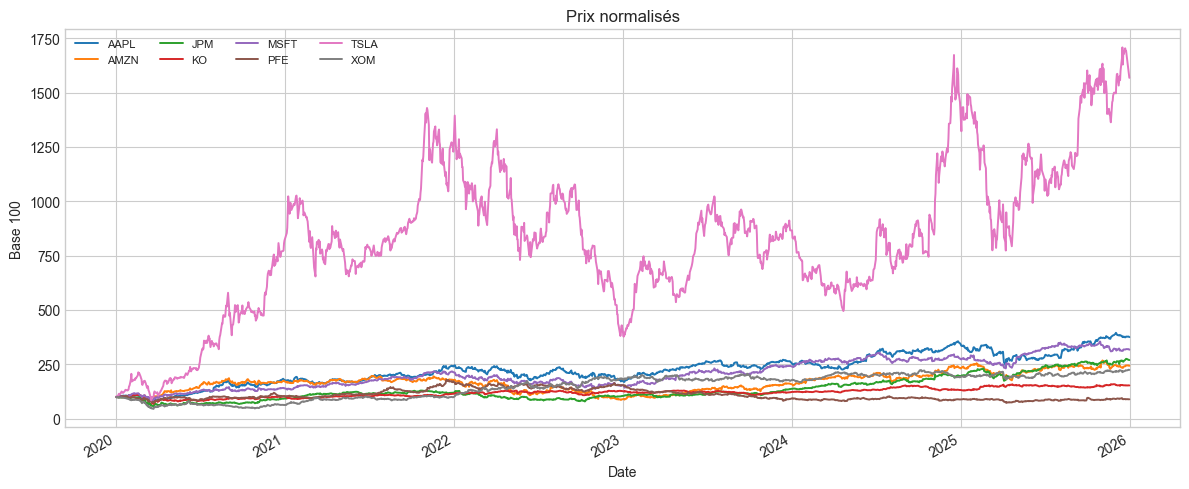

In [4]:
normalized_prices = prices / prices.iloc[0] * 100

fig, ax = plt.subplots(figsize=(12, 5))
normalized_prices.plot(ax=ax, linewidth=1.4)
ax.set_title("Prix normalisés")
ax.set_xlabel("Date")
ax.set_ylabel("Base 100")
ax.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()


## 4. Rendements et paramètres de marché

Les rendements logarithmiques sont utilisés pour estimer les paramètres:

$$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$$

La moyenne et la covariance journalières sont annualisées avec 252 jours de cotation.


In [5]:
simple_returns = prices.pct_change().dropna()
log_returns = np.log(prices / prices.shift(1)).dropna()

mu = log_returns.mean() * TRADING_DAYS
sigma = log_returns.cov() * TRADING_DAYS
vols = np.sqrt(np.diag(sigma))
corr = log_returns.corr()

asset_stats = pd.DataFrame({
    "return": mu,
    "volatility": vols,
    "sector": pd.Series(sector_map),
}).sort_values("return", ascending=False)

display(asset_stats)


,return,volatility,sector
TSLA,0.4602,0.6637,Consumer
AAPL,0.2211,0.3174,Technology
MSFT,0.1930,0.2954,Technology
JPM,0.1658,0.3133,Financials
AMZN,0.1486,0.3567,Consumer
XOM,0.1351,0.3283,Energy
KO,0.0709,0.2037,Defensive
PFE,-0.0194,0.2717,Healthcare


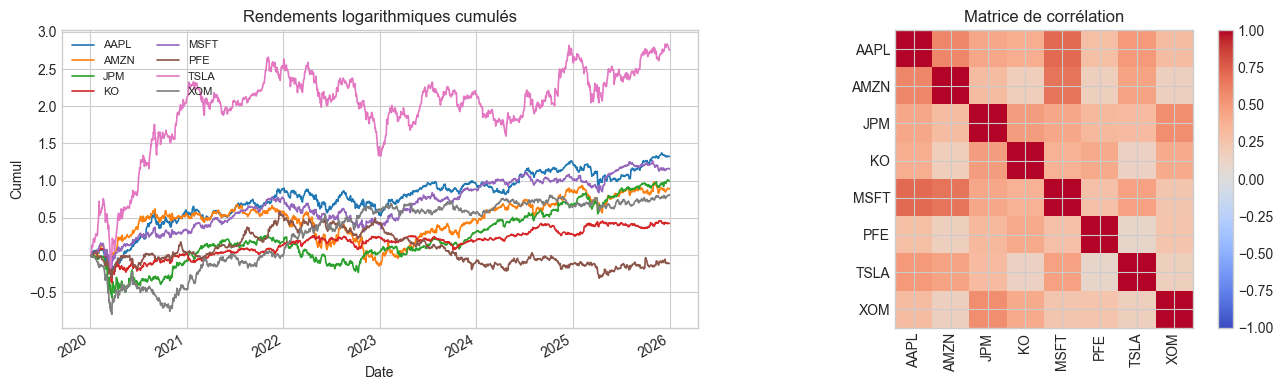

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

log_returns.cumsum().plot(ax=axes[0], linewidth=1.2)
axes[0].set_title("Rendements logarithmiques cumulés")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Cumul")
axes[0].legend(ncol=2, fontsize=8)

im = axes[1].imshow(corr.values, vmin=-1, vmax=1, cmap="coolwarm")
axes[1].set_title("Matrice de corrélation")
axes[1].set_xticks(range(len(assets)))
axes[1].set_yticks(range(len(assets)))
axes[1].set_xticklabels(assets, rotation=90)
axes[1].set_yticklabels(assets)
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


### Contrôle de la covariance

Une matrice de covariance doit être positive semi-définie.
En pratique, des erreurs numériques peuvent créer de très petites valeurs propres négatives.
Ce contrôle donne un repère rapide avant les optimisations.


In [7]:
eigenvalues = np.linalg.eigvalsh(sigma.values)

print("Valeurs propres de Sigma:")
print(eigenvalues)
print("Sigma positive semi-définie:", np.all(eigenvalues >= -1e-10))


Valeurs propres de Sigma:
[0.02274831 0.02510564 0.04245921 0.04338366 0.06407544 0.11507855
 0.19045806 0.5737518 ]
Sigma positive semi-définie: True


## 5. Fonctions principales

Les fonctions suivantes centralisent les calculs de rendement, variance, volatilité et Sharpe.
Elles sont utilisées ensuite par les optimiseurs et les tableaux de comparaison.
Les poids doivent être alignés avec l'ordre des colonnes de `prices`.


In [8]:
def rendement_portefeuille(weights, mu):
    """Compute annualized return."""
    return float(np.asarray(weights) @ np.asarray(mu))


def variance_portefeuille(weights, sigma):
    """Compute annualized variance."""
    weights = np.asarray(weights)
    sigma = np.asarray(sigma)
    return float(weights @ sigma @ weights)


def volatilite_portefeuille(weights, sigma):
    """Compute annualized volatility."""
    return float(np.sqrt(variance_portefeuille(weights, sigma)))


def ratio_sharpe(weights, mu, sigma, risk_free_rate=RISK_FREE_RATE):
    """Compute annualized Sharpe ratio."""
    vol = volatilite_portefeuille(weights, sigma)
    if vol == 0:
        return np.nan
    return (rendement_portefeuille(weights, mu) - risk_free_rate) / vol


def resume_portefeuille(name, weights, mu, sigma, risk_free_rate=RISK_FREE_RATE):
    """Return the main metrics for one allocation."""
    return {
        "name": name,
        "return": rendement_portefeuille(weights, mu),
        "volatility": volatilite_portefeuille(weights, sigma),
        "sharpe": ratio_sharpe(weights, mu, sigma, risk_free_rate),
    }


def table_poids(weights, assets, name="weight"):
    """Format weights as a sorted DataFrame."""
    return pd.DataFrame({"asset": assets, name: weights}).sort_values(name, ascending=False)


In [9]:
n_assets = len(assets)
w_equal = np.ones(n_assets) / n_assets

summary_equal = resume_portefeuille("Equal weight", w_equal, mu, sigma)
display(pd.DataFrame([summary_equal]).set_index("name"))
display(table_poids(w_equal, assets).style.format({"weight": "{:.2%}"}))


,return,volatility,sharpe
name,,,
Equal weight,0.1719,0.2287,0.6643


,asset,weight
0,AAPL,12.50%
1,AMZN,12.50%
2,JPM,12.50%
3,KO,12.50%
4,MSFT,12.50%
5,PFE,12.50%
6,TSLA,12.50%
7,XOM,12.50%


## 6. Optimisation minimum variance

Le portefeuille minimum variance cherche la volatilité la plus faible sous contraintes.
La contrainte principale impose que la somme des poids soit égale à 1.
Par défaut, les poids sont long-only et bornés par actif.


In [10]:
def full_investment_constraint():
    """Constraint enforcing weights that sum to one."""
    return {"type": "eq", "fun": lambda w: np.sum(w) - 1}


def long_only_bounds(n_assets, max_weight=MAX_WEIGHT):
    """Return long-only bounds for each asset."""
    return [(0, max_weight) for _ in range(n_assets)]


def validate_result(result):
    """Check optimizer status and normalize weights."""
    if not result.success:
        raise RuntimeError(result.message)
    weights = np.clip(result.x, 0, 1)
    return weights / weights.sum()


def optimize_min_variance(mu, sigma, bounds):
    """Minimize variance."""
    n_assets = len(mu)
    result = minimize(
        variance_portefeuille,
        x0=np.ones(n_assets) / n_assets,
        args=(sigma,),
        method="SLSQP",
        bounds=bounds,
        constraints=[full_investment_constraint()],
    )
    return validate_result(result)


In [11]:
bounds = long_only_bounds(n_assets, MAX_WEIGHT)
w_min_var = optimize_min_variance(mu, sigma, bounds)

summary_min_var = resume_portefeuille("Minimum variance", w_min_var, mu, sigma)
display(pd.DataFrame([summary_equal, summary_min_var]).set_index("name"))
display(table_poids(w_min_var, assets, "minimum_variance").style.format({"minimum_variance": "{:.2%}"}))


,return,volatility,sharpe
name,,,
Equal weight,0.1719,0.2287,0.6643
Minimum variance,0.0778,0.1799,0.3211


,asset,minimum_variance
3,KO,40.00%
5,PFE,24.94%
1,AMZN,13.55%
7,XOM,12.77%
4,MSFT,8.61%
2,JPM,0.14%
0,AAPL,0.00%
6,TSLA,0.00%


### Interprétation

Le minimum variance réduit la volatilité estimée en privilégiant les actifs moins risqués ou moins corrélés.
Le rendement attendu peut être plus faible que celui d'autres allocations.
Cette allocation sert souvent de point de comparaison défensif.


## 7. Optimisation maximum Sharpe

Le maximum Sharpe cherche le meilleur rendement excédentaire par unité de risque.
Comme `scipy.optimize.minimize` minimise une fonction, l'objectif utilisé est l'opposé du Sharpe.
Le résultat dépend fortement des estimations de $\mu$ et $\Sigma$.


In [12]:
def optimize_max_sharpe(mu, sigma, bounds, risk_free_rate=RISK_FREE_RATE, extra_constraints=None):
    """Maximize the Sharpe ratio with linear constraints."""
    n_assets = len(mu)
    constraints = [full_investment_constraint()]
    if extra_constraints is not None:
        constraints.extend(extra_constraints)

    def objective(weights):
        return -ratio_sharpe(weights, mu, sigma, risk_free_rate)

    result = minimize(
        objective,
        x0=np.ones(n_assets) / n_assets,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
    )
    return validate_result(result)


In [13]:
w_max_sharpe = optimize_max_sharpe(mu, sigma, bounds)

summaries = [
    summary_equal,
    summary_min_var,
    resume_portefeuille("Maximum Sharpe", w_max_sharpe, mu, sigma),
]
metrics = pd.DataFrame(summaries).set_index("name")
weights_comparison = pd.DataFrame({
    "Equal weight": w_equal,
    "Minimum variance": w_min_var,
    "Maximum Sharpe": w_max_sharpe,
}, index=assets)

display(metrics)
display(weights_comparison.style.format("{:.2%}"))


,return,volatility,sharpe
name,,,
Equal weight,0.1719,0.2287,0.6643
Minimum variance,0.0778,0.1799,0.3211
Maximum Sharpe,0.2558,0.3018,0.7814


,Equal weight,Minimum variance,Maximum Sharpe
AAPL,12.50%,0.00%,28.45%
AMZN,12.50%,13.55%,0.00%
JPM,12.50%,0.14%,12.81%
KO,12.50%,40.00%,0.00%
MSFT,12.50%,8.61%,19.82%
PFE,12.50%,24.94%,0.00%
TSLA,12.50%,0.00%,24.88%
XOM,12.50%,12.77%,14.04%


## 8. Rendement maximal sous volatilité cible

Cette optimisation impose une volatilité maximale et cherche le rendement le plus élevé.
Elle est utile quand le niveau de risque est fixé à l'avance.
Si la cible est trop basse, le problème peut devenir irréalisable.


In [14]:
def optimize_max_return_target_vol(mu, sigma, target_vol=0.20, max_weight=MAX_WEIGHT):
    """Maximize expected return under a volatility limit."""
    n_assets = len(mu)
    bounds = long_only_bounds(n_assets, max_weight)
    constraints = [
        full_investment_constraint(),
        {"type": "ineq", "fun": lambda w: target_vol - volatilite_portefeuille(w, sigma)},
    ]

    result = minimize(
        lambda w: -rendement_portefeuille(w, mu),
        x0=np.ones(n_assets) / n_assets,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
    )
    return validate_result(result)


In [15]:
target_vol = 0.22

try:
    w_target_vol = optimize_max_return_target_vol(mu, sigma, target_vol=target_vol)
    metrics.loc["Target volatility"] = resume_portefeuille("Target volatility", w_target_vol, mu, sigma)
    weights_comparison["Target volatility"] = w_target_vol
except RuntimeError as exc:
    print(f"Optimisation non réalisable: {exc}")
    w_target_vol = None

display(metrics)
display(weights_comparison.style.format("{:.2%}"))


,return,volatility,sharpe
name,,,
Equal weight,0.1719,0.2287,0.6643
Minimum variance,0.0778,0.1799,0.3211
Maximum Sharpe,0.2558,0.3018,0.7814
Target volatility,0.1773,0.2200,0.7148


,Equal weight,Minimum variance,Maximum Sharpe,Target volatility
AAPL,12.50%,0.00%,28.45%,15.40%
AMZN,12.50%,13.55%,0.00%,0.00%
JPM,12.50%,0.14%,12.81%,7.06%
KO,12.50%,40.00%,0.00%,32.23%
MSFT,12.50%,8.61%,19.82%,20.29%
PFE,12.50%,24.94%,0.00%,0.00%
TSLA,12.50%,0.00%,24.88%,10.98%
XOM,12.50%,12.77%,14.04%,14.03%


## 9. Contraintes sectorielles

Une contrainte sectorielle limite la concentration dans un même groupe d'actifs.
Elle ne change pas l'objectif d'optimisation, mais réduit l'ensemble des allocations admissibles.
La comparaison montre l'effet de cette contrainte sur les poids et les métriques.


In [16]:
def exposition_secteur(weights, assets, sector_map):
    """Aggregate weights by sector."""
    df = pd.DataFrame({
        "asset": assets,
        "sector": [sector_map.get(asset, "Other") for asset in assets],
        "weight": weights,
    })
    return df.groupby("sector")["weight"].sum().sort_values(ascending=False)


def sector_constraints(assets, sector_map, max_sector_weight):
    """Build max exposure constraints by sector."""
    constraints = []
    sectors = sorted(set(sector_map.values()))
    for sector in sectors:
        indices = [i for i, asset in enumerate(assets) if sector_map.get(asset, "Other") == sector]
        constraints.append({
            "type": "ineq",
            "fun": lambda w, idx=indices: max_sector_weight - np.sum(w[idx]),
        })
    return constraints


In [17]:
constraints = sector_constraints(assets, sector_map, MAX_SECTOR_WEIGHT)
w_sector = optimize_max_sharpe(mu, sigma, bounds, extra_constraints=constraints)

metrics.loc["Maximum Sharpe constrained"] = resume_portefeuille("Maximum Sharpe constrained", w_sector, mu, sigma)
weights_comparison["Maximum Sharpe constrained"] = w_sector

sector_table = pd.DataFrame({
    "Maximum Sharpe": exposition_secteur(w_max_sharpe, assets, sector_map),
    "Constrained": exposition_secteur(w_sector, assets, sector_map),
}).fillna(0)

display(metrics)
display(sector_table.style.format("{:.2%}"))


,return,volatility,sharpe
name,,,
Equal weight,0.1719,0.2287,0.6643
Minimum variance,0.0778,0.1799,0.3211
Maximum Sharpe,0.2558,0.3018,0.7814
Target volatility,0.1773,0.2200,0.7148
Maximum Sharpe constrained,0.2558,0.3018,0.7814


,Maximum Sharpe,Constrained
sector,,
Technology,48.27%,48.27%
Consumer,24.88%,24.88%
Energy,14.04%,14.04%
Financials,12.81%,12.81%
Healthcare,0.00%,0.00%
Defensive,0.00%,0.00%


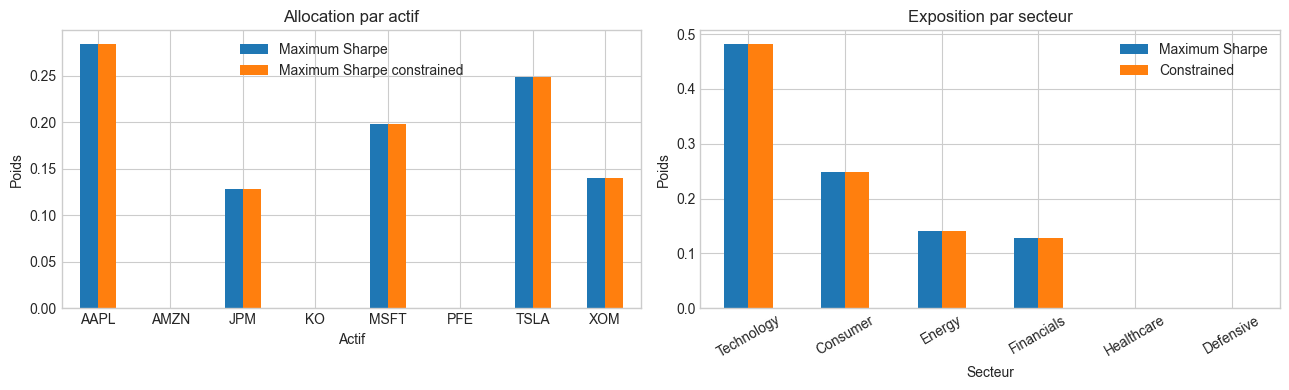

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

weights_comparison[["Maximum Sharpe", "Maximum Sharpe constrained"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Allocation par actif")
axes[0].set_xlabel("Actif")
axes[0].set_ylabel("Poids")
axes[0].tick_params(axis="x", rotation=0)

sector_table.plot(kind="bar", ax=axes[1])
axes[1].set_title("Exposition par secteur")
axes[1].set_xlabel("Secteur")
axes[1].set_ylabel("Poids")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


## 10. Comparaison des portefeuilles

Le tableau compare rendement annualisé, volatilité annualisée et Sharpe.
Les poids indiquent les actifs qui expliquent le plus chaque allocation.
Il faut surtout regarder les différences de risque et de concentration.


,return,volatility,sharpe
name,,,
Maximum Sharpe constrained,0.2558,0.3018,0.7814
Maximum Sharpe,0.2558,0.3018,0.7814
Target volatility,0.1773,0.2200,0.7148
Equal weight,0.1719,0.2287,0.6643
Minimum variance,0.0778,0.1799,0.3211


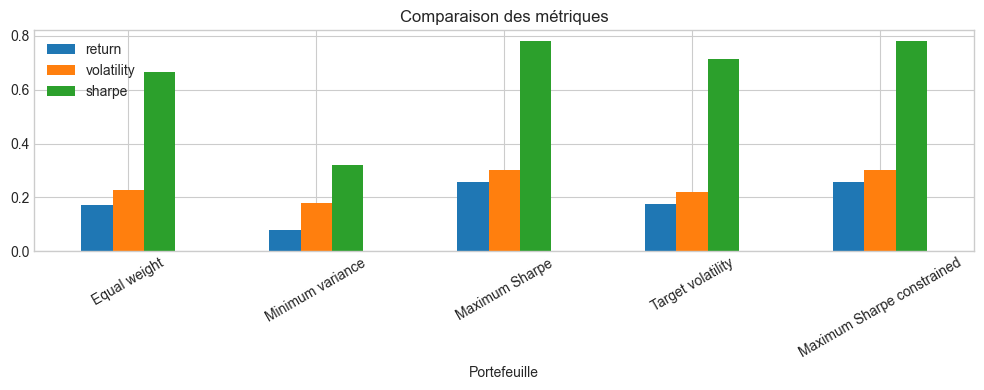

In [19]:
display(metrics.sort_values("sharpe", ascending=False))

fig, ax = plt.subplots(figsize=(10, 4))
metrics[["return", "volatility", "sharpe"]].plot(kind="bar", ax=ax)
ax.set_title("Comparaison des métriques")
ax.set_xlabel("Portefeuille")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()


## 11. Frontière efficiente simulée

La simulation génère des poids aléatoires long-only et calcule rendement, volatilité et Sharpe.
Elle donne une lecture intuitive du compromis rendement-risque.
Les portefeuilles optimisés sont ajoutés au graphique comme points de repère.


In [20]:
def simulate_allocations(n_simulations, mu, sigma, seed=SEED):
    """Simulate random long-only allocations."""
    rng = np.random.default_rng(seed)
    n_assets = len(mu)
    weights = rng.dirichlet(np.ones(n_assets), size=n_simulations)
    returns = weights @ mu.values
    variances = np.einsum("ij,jk,ik->i", weights, sigma.values, weights)
    vols = np.sqrt(variances)
    sharpes = (returns - RISK_FREE_RATE) / vols
    data = pd.DataFrame({"return": returns, "volatility": vols, "sharpe": sharpes})
    return data, weights


random_allocations, random_weights = simulate_allocations(N_SIMULATIONS, mu, sigma)
display(random_allocations.describe())


,return,volatility,sharpe
count,"10,000.0000","10,000.0000","10,000.0000"
mean,0.1719,0.2448,0.6113
std,0.0434,0.0396,0.0970
min,0.0272,0.1793,0.0298
25%,0.1433,0.2188,0.5574
50%,0.1675,0.2360,0.6292
75%,0.1957,0.2597,0.6850
max,0.3737,0.5095,0.7727


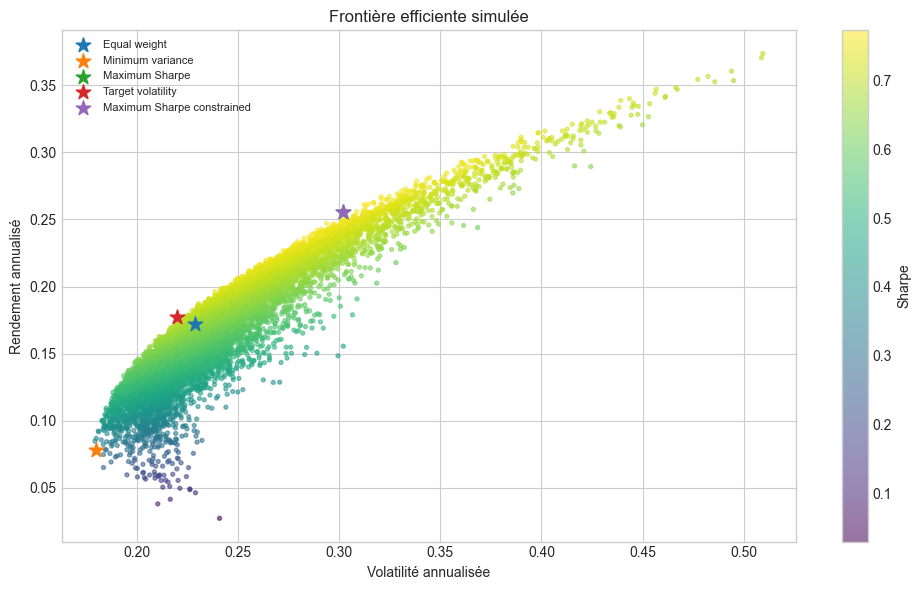

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(
    random_allocations["volatility"],
    random_allocations["return"],
    c=random_allocations["sharpe"],
    s=8,
    alpha=0.55,
    cmap="viridis",
)

for name, row in metrics.iterrows():
    ax.scatter(row["volatility"], row["return"], s=120, marker="*", label=name)

ax.set_title("Frontière efficiente simulée")
ax.set_xlabel("Volatilité annualisée")
ax.set_ylabel("Rendement annualisé")
ax.legend(fontsize=8)
fig.colorbar(scatter, ax=ax, label="Sharpe")
plt.tight_layout()
plt.show()


### Lecture du graphique

Les points représentent des allocations aléatoires admissibles.
Les portefeuilles optimisés doivent se situer sur des zones cohérentes du nuage rendement-risque.
Un point isolé peut signaler une estimation de rendement très dominante ou une contrainte peu restrictive.


## 12. Mesures de risque historiques

La VaR mesure une perte seuil à un niveau de confiance donné.
La CVaR mesure la perte moyenne au-delà de ce seuil.
Le drawdown mesure la baisse du capital par rapport à son précédent plus haut.


In [22]:
def rendements_realises(simple_returns, weights):
    """Compute realized returns."""
    return simple_returns @ weights


def var_cvar(returns, alpha=0.95):
    """Compute historical VaR and CVaR on losses."""
    losses = -returns.dropna()
    var = np.quantile(losses, alpha)
    cvar = losses[losses >= var].mean()
    return float(var), float(cvar)


def drawdown_series(returns):
    """Compute drawdown from simple returns."""
    wealth = (1 + returns).cumprod()
    running_max = wealth.cummax()
    return wealth / running_max - 1


In [23]:
risk_rows = []
for name in weights_comparison.columns:
    weights = weights_comparison[name].values
    realized = rendements_realises(simple_returns, weights)
    var_95, cvar_95 = var_cvar(realized, alpha=0.95)
    risk_rows.append({
        "name": name,
        "VaR 95% daily": var_95,
        "CVaR 95% daily": cvar_95,
        "max drawdown": drawdown_series(realized).min(),
    })

risk_metrics = pd.DataFrame(risk_rows).set_index("name")
display(risk_metrics)


,VaR 95% daily,CVaR 95% daily,max drawdown
name,,,
Equal weight,0.0208,0.0343,-0.3441
Minimum variance,0.0155,0.0267,-0.3129
Maximum Sharpe,0.0280,0.0434,-0.3967
Target volatility,0.0181,0.0329,-0.3756
Maximum Sharpe constrained,0.0280,0.0434,-0.3967


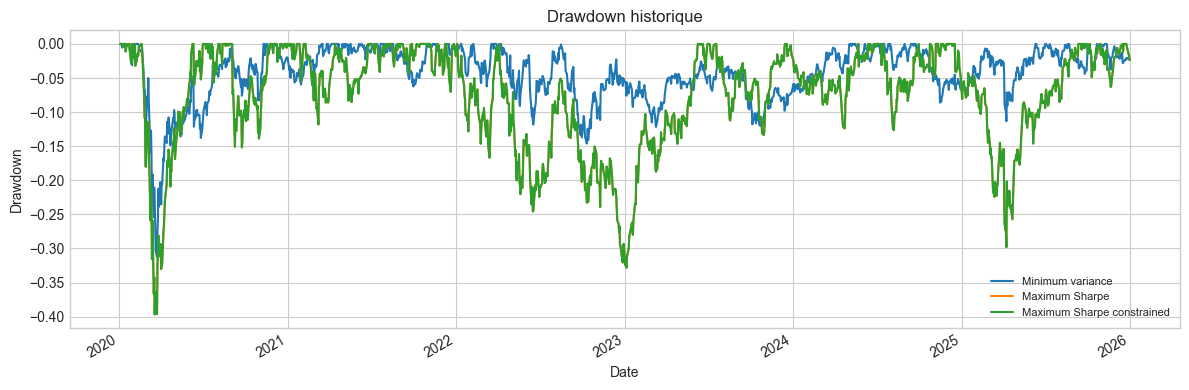

In [24]:
fig, ax = plt.subplots(figsize=(12, 4))

for name in ["Minimum variance", "Maximum Sharpe", "Maximum Sharpe constrained"]:
    realized = rendements_realises(simple_returns, weights_comparison[name].values)
    drawdown_series(realized).plot(ax=ax, label=name)

ax.set_title("Drawdown historique")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 13. Monte Carlo de rendements corrélés

La simulation Monte Carlo génère des rendements futurs cohérents avec la covariance estimée.
Le portefeuille retenu ici est le maximum Sharpe contraint.
Le résultat décrit une distribution de scénarios, pas une prévision déterministe.


In [25]:
def simulate_terminal_returns(mu, sigma, weights, horizon_days=TRADING_DAYS, n_sims=20_000, seed=SEED):
    """Simulate terminal returns from correlated normal log-returns."""
    rng = np.random.default_rng(seed)
    daily_mu = mu.values / TRADING_DAYS
    daily_sigma = sigma.values / TRADING_DAYS
    simulated = rng.multivariate_normal(daily_mu, daily_sigma, size=(n_sims, horizon_days))
    simulated_allocation = simulated @ weights
    terminal_returns = np.exp(simulated_allocation.sum(axis=1)) - 1
    return pd.Series(terminal_returns, name="terminal_return")


mc_returns = simulate_terminal_returns(mu, sigma, w_sector)
mc_summary = mc_returns.describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99])
display(mc_summary.to_frame("Monte Carlo"))


,Monte Carlo
count,"20,000.0000"
mean,0.3500
std,0.4161
min,-0.5863
1%,-0.3657
5%,-0.2180
50%,0.2905
95%,1.1193
99%,1.6039
max,3.1206


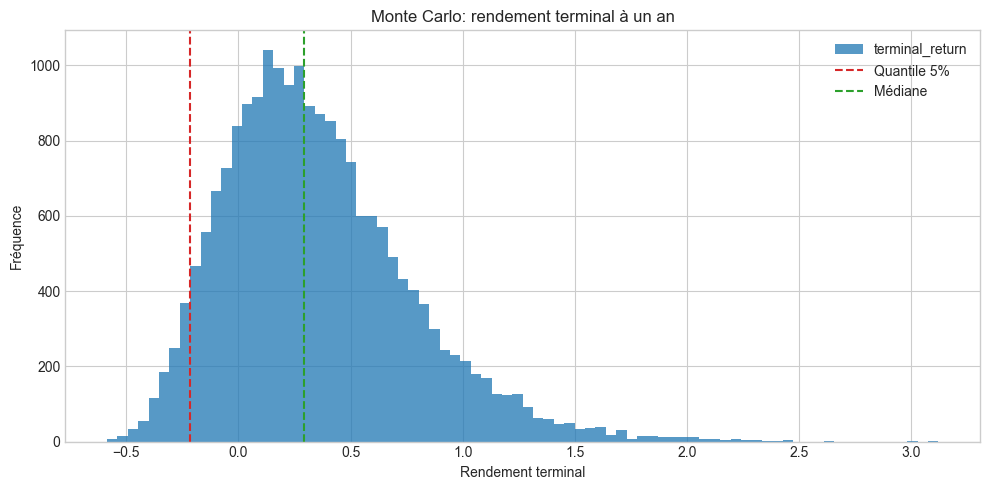

In [26]:
fig, ax = plt.subplots(figsize=(10, 5))
mc_returns.plot(kind="hist", bins=80, alpha=0.75, ax=ax)
ax.axvline(mc_returns.quantile(0.05), linestyle="--", color="tab:red", label="Quantile 5%")
ax.axvline(mc_returns.median(), linestyle="--", color="tab:green", label="Médiane")
ax.set_title("Monte Carlo: rendement terminal à un an")
ax.set_xlabel("Rendement terminal")
ax.set_ylabel("Fréquence")
ax.legend()
plt.tight_layout()
plt.show()


## 14. Backtest train/test

Les paramètres sont estimés sur la première partie de l'historique.
Les portefeuilles sont ensuite évalués sur la période restante.
Ce test reste simple, mais il évite de juger une allocation uniquement sur les données qui ont servi à l'optimiser.


In [27]:
def performance_realisee(returns, risk_free_rate=RISK_FREE_RATE):
    """Compute annualized realized performance metrics."""
    ann_return = (1 + returns).prod() ** (TRADING_DAYS / len(returns)) - 1
    ann_vol = returns.std() * np.sqrt(TRADING_DAYS)
    sharpe = (ann_return - risk_free_rate) / ann_vol if ann_vol > 0 else np.nan
    return pd.Series({
        "return": ann_return,
        "volatility": ann_vol,
        "sharpe": sharpe,
        "max drawdown": drawdown_series(returns).min(),
    })


split_idx = int(len(log_returns) * 0.70)
train_log_returns = log_returns.iloc[:split_idx]
test_simple_returns = simple_returns.iloc[split_idx:]

mu_train = train_log_returns.mean() * TRADING_DAYS
sigma_train = train_log_returns.cov() * TRADING_DAYS
bounds_train = long_only_bounds(len(mu_train), MAX_WEIGHT)
constraints_train = sector_constraints(assets, sector_map, MAX_SECTOR_WEIGHT)

backtest_weights = {
    "Equal weight": w_equal,
    "Minimum variance": optimize_min_variance(mu_train, sigma_train, bounds_train),
    "Maximum Sharpe": optimize_max_sharpe(mu_train, sigma_train, bounds_train),
    "Maximum Sharpe constrained": optimize_max_sharpe(
        mu_train,
        sigma_train,
        bounds_train,
        extra_constraints=constraints_train,
    ),
}

backtest_returns = pd.DataFrame({
    name: rendements_realises(test_simple_returns, weights)
    for name, weights in backtest_weights.items()
})

backtest_metrics = backtest_returns.apply(performance_realisee).T
display(backtest_metrics)


,return,volatility,sharpe,max drawdown
Equal weight,0.2564,0.1810,1.3061,-0.2050
Minimum variance,0.1052,0.1338,0.6368,-0.1161
Maximum Sharpe,0.2944,0.2467,1.1122,-0.2824
Maximum Sharpe constrained,0.2944,0.2467,1.1122,-0.2824


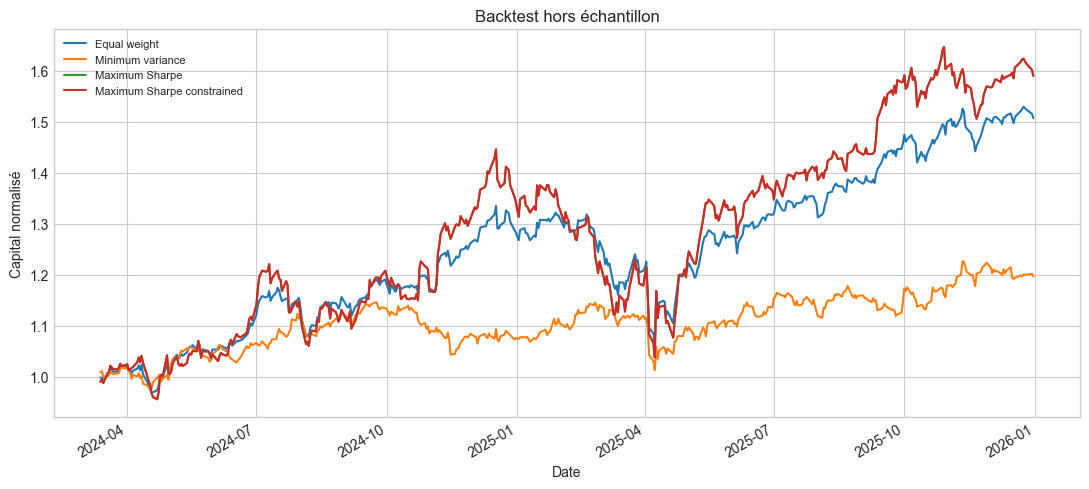

In [28]:
fig, ax = plt.subplots(figsize=(11, 5))
(1 + backtest_returns).cumprod().plot(ax=ax, linewidth=1.5)
ax.set_title("Backtest hors échantillon")
ax.set_xlabel("Date")
ax.set_ylabel("Capital normalisé")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


### Lecture du backtest

La performance hors échantillon peut différer fortement de l'optimisation initiale.
C'est normal: les rendements attendus et les corrélations sont instables.
Une analyse plus robuste testerait plusieurs fenêtres et des rééquilibrages périodiques.


## 15. Shrinkage de covariance

La covariance empirique peut être instable lorsque l'échantillon est limité.
Le shrinkage Ledoit-Wolf régularise l'estimation en la rapprochant d'une structure plus stable.
La comparaison ci-dessous isole l'effet de cette estimation sur le maximum Sharpe.


In [29]:
try:
    from sklearn.covariance import LedoitWolf

    lw = LedoitWolf().fit(log_returns.values)
    sigma_lw = pd.DataFrame(lw.covariance_ * TRADING_DAYS, index=assets, columns=assets)
    w_lw = optimize_max_sharpe(mu, sigma_lw, bounds)

    shrinkage_metrics = pd.DataFrame([
        resume_portefeuille("Sample covariance", w_max_sharpe, mu, sigma),
        resume_portefeuille("Ledoit-Wolf", w_lw, mu, sigma_lw),
    ]).set_index("name")
    shrinkage_weights = pd.DataFrame({
        "Sample covariance": w_max_sharpe,
        "Ledoit-Wolf": w_lw,
    }, index=assets)

    display(shrinkage_metrics)
    display(shrinkage_weights.style.format("{:.2%}"))
except Exception as exc:
    print(f"Shrinkage non exécuté: {exc}")


,return,volatility,sharpe
name,,,
Sample covariance,0.2558,0.3018,0.7814
Ledoit-Wolf,0.2562,0.3008,0.7850


,Sample covariance,Ledoit-Wolf
AAPL,28.45%,28.16%
AMZN,0.00%,0.00%
JPM,12.81%,13.00%
KO,0.00%,0.00%
MSFT,19.82%,19.79%
PFE,0.00%,0.00%
TSLA,24.88%,25.04%
XOM,14.04%,14.01%


## 16. Clustering de profils investisseurs

On ajoute ici une couche ML simple pour segmenter des investisseurs.
Comme le notebook ne contient pas de fichier client, on simule un petit questionnaire avec des variables lisibles: âge, horizon, tolérance au drawdown, connaissance financière et besoin de liquidité.
Le clustering ne connaît pas les profils à l'avance; les labels sont ajoutés après coup en lisant les moyennes de chaque groupe.


,risk_profile,n_investors,risk_aversion,age,horizon_years,drawdown_tolerance,knowledge_score,liquidity_need
cluster,,,,,,,,
0,Prudent,77,20.0,58,4.0,8.5%,2.0,75.9%
2,Equilibre,101,8.0,41,8.8,15.9%,3.2,43.1%
1,Dynamique,62,2.0,31,18.0,30.2%,4.4,19.4%


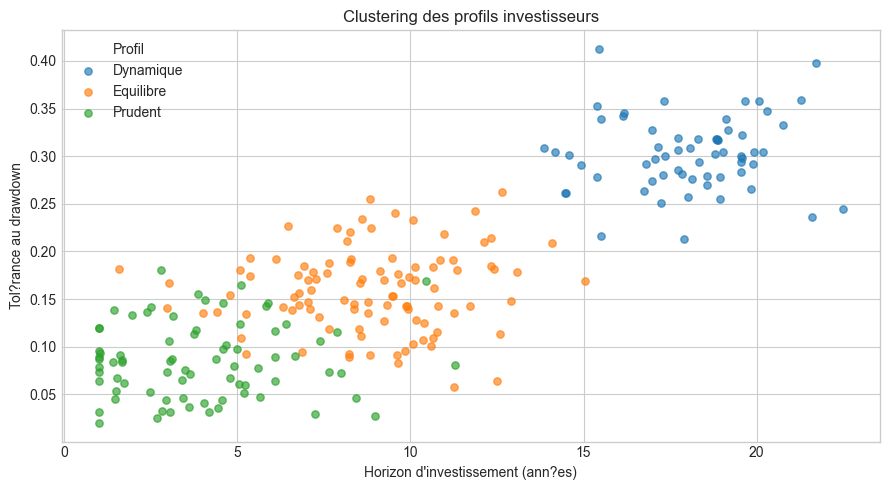

In [30]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


def simulate_investor_profiles(n_investors=240, seed=SEED):
    """Generate simple investor questionnaire data."""
    rng = np.random.default_rng(seed)
    archetypes = pd.DataFrame({
        "archetype": ["Prudent", "Equilibre", "Dynamique"],
        "age": [58, 42, 30],
        "horizon_years": [4, 9, 18],
        "drawdown_tolerance": [0.08, 0.16, 0.30],
        "knowledge_score": [2.0, 3.2, 4.4],
        "liquidity_need": [0.75, 0.45, 0.20],
    })
    sizes = rng.multinomial(n_investors, [0.35, 0.40, 0.25])

    rows = []
    for size, (_, profile) in zip(sizes, archetypes.iterrows()):
        sample = pd.DataFrame({
            "age": rng.normal(profile["age"], 7, size),
            "horizon_years": rng.normal(profile["horizon_years"], 2.5, size),
            "drawdown_tolerance": rng.normal(profile["drawdown_tolerance"], 0.04, size),
            "knowledge_score": rng.normal(profile["knowledge_score"], 0.6, size),
            "liquidity_need": rng.normal(profile["liquidity_need"], 0.12, size),
        })
        rows.append(sample)

    investors = pd.concat(rows, ignore_index=True)
    investors["age"] = investors["age"].clip(18, 75).round(0)
    investors["horizon_years"] = investors["horizon_years"].clip(1, 30)
    investors["drawdown_tolerance"] = investors["drawdown_tolerance"].clip(0.02, 0.45)
    investors["knowledge_score"] = investors["knowledge_score"].clip(1, 5)
    investors["liquidity_need"] = investors["liquidity_need"].clip(0, 1)
    return investors.sample(frac=1, random_state=seed).reset_index(drop=True)


investor_features = [
    "age",
    "horizon_years",
    "drawdown_tolerance",
    "knowledge_score",
    "liquidity_need",
]

investors = simulate_investor_profiles()
scaler = StandardScaler()
X_investors = scaler.fit_transform(investors[investor_features])

kmeans = KMeans(n_clusters=3, random_state=SEED, n_init=10)
investors["cluster"] = kmeans.fit_predict(X_investors)

profile_summary = investors.groupby("cluster").agg(
    n_investors=("cluster", "size"),
    age=("age", "mean"),
    horizon_years=("horizon_years", "mean"),
    drawdown_tolerance=("drawdown_tolerance", "mean"),
    knowledge_score=("knowledge_score", "mean"),
    liquidity_need=("liquidity_need", "mean"),
)

risk_appetite = (
    profile_summary["horizon_years"].rank()
    + profile_summary["drawdown_tolerance"].rank()
    + profile_summary["knowledge_score"].rank()
    + profile_summary["liquidity_need"].rank(ascending=False)
)
ordered_clusters = risk_appetite.sort_values().index
profile_labels = ["Prudent", "Equilibre", "Dynamique"]
risk_aversions = [20.0, 8.0, 2.0]

profile_map = dict(zip(ordered_clusters, profile_labels))
aversion_map = dict(zip(ordered_clusters, risk_aversions))

investors["risk_profile"] = investors["cluster"].map(profile_map)
investors["risk_aversion"] = investors["cluster"].map(aversion_map)
profile_summary["risk_profile"] = profile_summary.index.map(profile_map)
profile_summary["risk_aversion"] = profile_summary.index.map(aversion_map)

profile_summary = profile_summary.sort_values("risk_aversion", ascending=False)
display(profile_summary[[
    "risk_profile",
    "n_investors",
    "risk_aversion",
    "age",
    "horizon_years",
    "drawdown_tolerance",
    "knowledge_score",
    "liquidity_need",
]].style.format({
    "age": "{:.0f}",
    "horizon_years": "{:.1f}",
    "drawdown_tolerance": "{:.1%}",
    "knowledge_score": "{:.1f}",
    "liquidity_need": "{:.1%}",
    "risk_aversion": "{:.1f}",
}))

fig, ax = plt.subplots(figsize=(9, 5))
for profile, group in investors.groupby("risk_profile"):
    ax.scatter(
        group["horizon_years"],
        group["drawdown_tolerance"],
        s=28,
        alpha=0.65,
        label=profile,
    )

ax.set_title("Clustering des profils investisseurs")
ax.set_xlabel("Horizon d'investissement (ann?es)")
ax.set_ylabel("Tol?rance au drawdown")
ax.legend(title="Profil")
plt.tight_layout()
plt.show()


### Portefeuille associé à chaque profil

L'aversion au risque est notée $\gamma$.
Plus $\gamma$ est élevé, plus l'investisseur pénalise la variance du portefeuille.
On maximise donc une utilité moyenne-variance simple:

$$U(w) = w^\top\mu - \frac{\gamma}{2}w^\top\Sigma w$$


,risk_aversion,return,volatility,sharpe
name,,,,
Prudent,20.0000,0.1087,0.1845,0.4806
Equilibre,8.0000,0.1565,0.2053,0.6650
Dynamique,2.0000,0.2830,0.3395,0.7749


,Prudent (gamma=20.0),Equilibre (gamma=8.0),Dynamique (gamma=2.0)
AAPL,4.27%,11.58%,31.90%
AMZN,9.69%,2.70%,0.00%
JPM,2.63%,5.56%,10.32%
KO,40.00%,40.00%,0.00%
MSFT,13.52%,18.81%,14.37%
PFE,14.10%,0.00%,0.00%
TSLA,2.28%,7.44%,33.54%
XOM,13.50%,13.91%,9.88%


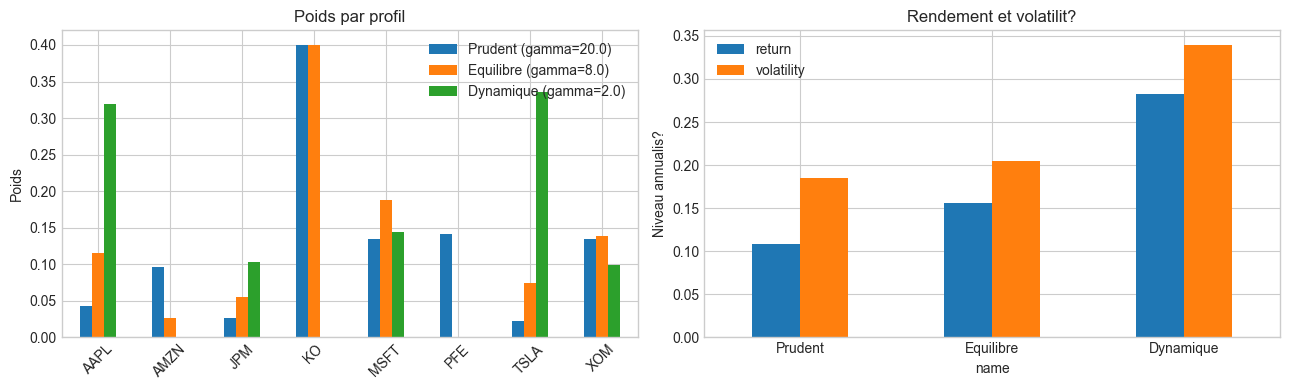

In [31]:
def optimize_mean_variance_utility(mu, sigma, bounds, risk_aversion, extra_constraints=None):
    """Maximize a simple mean-variance utility."""
    n_assets = len(mu)
    constraints_mv = [full_investment_constraint()]
    if extra_constraints is not None:
        constraints_mv.extend(extra_constraints)

    def objective(weights):
        utility = rendement_portefeuille(weights, mu) - 0.5 * risk_aversion * variance_portefeuille(weights, sigma)
        return -utility

    result = minimize(
        objective,
        x0=np.ones(n_assets) / n_assets,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints_mv,
    )
    return validate_result(result)


profile_allocations = {}
profile_rows = []
for _, profile in profile_summary.iterrows():
    name = profile["risk_profile"]
    gamma = profile["risk_aversion"]
    weights = optimize_mean_variance_utility(mu, sigma, bounds, gamma, extra_constraints=constraints)
    profile_allocations[f"{name} (gamma={gamma:.1f})"] = weights

    row = resume_portefeuille(name, weights, mu, sigma)
    row["risk_aversion"] = gamma
    profile_rows.append(row)

profile_metrics = pd.DataFrame(profile_rows).set_index("name")
profile_weights = pd.DataFrame(profile_allocations, index=assets)

display(profile_metrics[["risk_aversion", "return", "volatility", "sharpe"]])
display(profile_weights.style.format("{:.2%}"))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
profile_weights.plot(kind="bar", ax=axes[0])
profile_metrics[["return", "volatility"]].plot(kind="bar", ax=axes[1])

axes[0].set_title("Poids par profil")
axes[0].set_ylabel("Poids")
axes[1].set_title("Rendement et volatilit?")
axes[1].set_ylabel("Niveau annualis?")
axes[0].tick_params(axis="x", rotation=45)
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()


## 17. Limites

Les résultats dépendent de la période observée, de l'univers d'actifs et des hypothèses de covariance.
Les rendements attendus historiques sont bruités et peuvent produire des allocations concentrées.
Le backtest ignore les frais, la fiscalité, la liquidité et les rééquilibrages.
Pour aller plus loin, il faudrait tester plusieurs fenêtres temporelles et intégrer des coûts de transaction.
